# 10_Skill_Archetype_Clustering
Standardize features, determine optimal K, cluster skills, assign archetypes, and save master_skill_dataset_v8.csv

In [28]:

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt


In [29]:

df = pd.read_csv('../Generated Datasets/expanded_skill_master.csv')

print(df.shape)
df.head()


(114, 9)


,skill,sub_category,linkedin_demand,salary_premium,current_usage,future_interest,global_adoption_score,growth_rate,history_found
0,data analysis,Data Analytics,1.000000,0.326209,0.000000,0.000000,160.0,0.566533,0
1,excel,Data Analytics,0.506295,0.067637,0.000000,0.000000,160.0,0.566533,0
2,quality assurance,Software Engineering,0.442621,0.175857,0.000000,0.000000,160.0,0.566533,0
3,microsoft excel,Data Analytics,0.314443,0.067637,0.000000,0.000000,160.0,0.566533,0
4,python,Programming,0.307062,0.631282,0.876458,0.701599,173.0,0.255955,1


## Features for Clustering

In [30]:

feature_cols = [
    'linkedin_demand',
    'salary_premium',
    'current_usage',
    'future_interest',
    'global_adoption_score',
    'growth_rate'
]

X = df[feature_cols].copy()


## Standardize Features

In [31]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [32]:
from sklearn.preprocessing import MinMaxScaler

df['global_adoption_score'] = (
    MinMaxScaler()
    .fit_transform(
        df[['global_adoption_score']]
    )
)

## Elbow Method

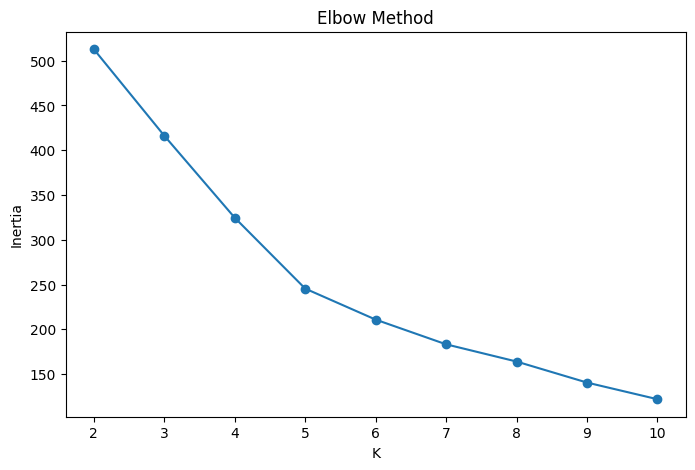

In [33]:

inertias = []

for k in range(2,11):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), inertias, marker='o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()


## Silhouette Analysis

,K,Silhouette
0,2,0.470133
1,3,0.387092
2,4,0.454897
3,5,0.349837
4,6,0.314203
5,7,0.319838
6,8,0.330585
7,9,0.348963
8,10,0.374163


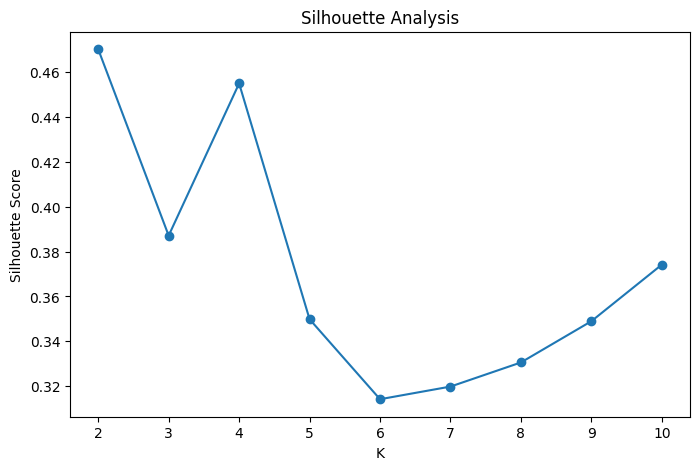

In [34]:

sil_scores = []

for k in range(2,11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = km.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    sil_scores.append(score)

sil_df = pd.DataFrame({
    'K': range(2,11),
    'Silhouette': sil_scores
})

display(sil_df)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), sil_scores, marker='o')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.show()


## Final Clustering

In [35]:

final_k = 4

kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=20
)

df['cluster'] = kmeans.fit_predict(X_scaled)

cluster_summary = (
    df.groupby('cluster')[feature_cols]
    .mean()
    .round(3)
)

display(cluster_summary)


,linkedin_demand,salary_premium,current_usage,future_interest,global_adoption_score,growth_rate
cluster,,,,,,
0,0.076,0.639,0.425,0.422,0.931,0.157
1,0.047,0.550,0.012,0.023,0.911,0.432
2,0.566,0.159,0.000,0.000,0.914,0.567
3,0.110,0.564,0.222,0.159,0.000,0.604


## Archetype Assignment

In [36]:

cluster_summary['cluster_score'] = (
      0.30*cluster_summary['linkedin_demand']
    + 0.25*cluster_summary['future_interest']
    + 0.25*cluster_summary['growth_rate']
    + 0.10*cluster_summary['current_usage']
    + 0.10*cluster_summary['global_adoption_score']
)

ranked = (
    cluster_summary['cluster_score']
    .sort_values(ascending=False)
    .index
    .tolist()
)

archetype_map = {
    ranked[0]: 'Future-Proof',
    ranked[1]: 'Growing',
    ranked[2]: 'Stable',
    ranked[3]: 'High-Risk'
}

df['archetype'] = (
    df['cluster']
    .map(archetype_map)
)

print(df['archetype'].value_counts())
display(cluster_summary)


archetype
High-Risk       89
Growing         17
Future-Proof     4
Stable           4
Name: count, dtype: int64


,linkedin_demand,salary_premium,current_usage,future_interest,global_adoption_score,growth_rate,cluster_score
cluster,,,,,,,
0,0.076,0.639,0.425,0.422,0.931,0.157,0.30315
1,0.047,0.550,0.012,0.023,0.911,0.432,0.22015
2,0.566,0.159,0.000,0.000,0.914,0.567,0.40295
3,0.110,0.564,0.222,0.159,0.000,0.604,0.24595


## Save Outputs

In [37]:

df.to_csv(
    '../Generated Datasets/master_skill_dataset_v8.csv',
    index=False
)

cluster_summary.to_csv(
    '../Generated Datasets/cluster_summary.csv'
)

print('Saved Successfully')
print(df.shape)

df[['skill','cluster','archetype']].head()


Saved Successfully
(114, 11)


,skill,cluster,archetype
0,data analysis,2,Future-Proof
1,excel,2,Future-Proof
2,quality assurance,2,Future-Proof
3,microsoft excel,2,Future-Proof
4,python,0,Growing


In [38]:
print(df.shape)

print(
    df[df['skill'].isin([
        'llm',
        'langchain',
        'rag'
    ])]
)

(114, 11)
Empty DataFrame
Columns: [skill, sub_category, linkedin_demand, salary_premium, current_usage, future_interest, global_adoption_score, growth_rate, history_found, cluster, archetype]
Index: []


In [39]:
print(df['archetype'].value_counts())

archetype
High-Risk       89
Growing         17
Future-Proof     4
Stable           4
Name: count, dtype: int64


In [40]:
display(cluster_summary)

,linkedin_demand,salary_premium,current_usage,future_interest,global_adoption_score,growth_rate,cluster_score
cluster,,,,,,,
0,0.076,0.639,0.425,0.422,0.931,0.157,0.30315
1,0.047,0.550,0.012,0.023,0.911,0.432,0.22015
2,0.566,0.159,0.000,0.000,0.914,0.567,0.40295
3,0.110,0.564,0.222,0.159,0.000,0.604,0.24595


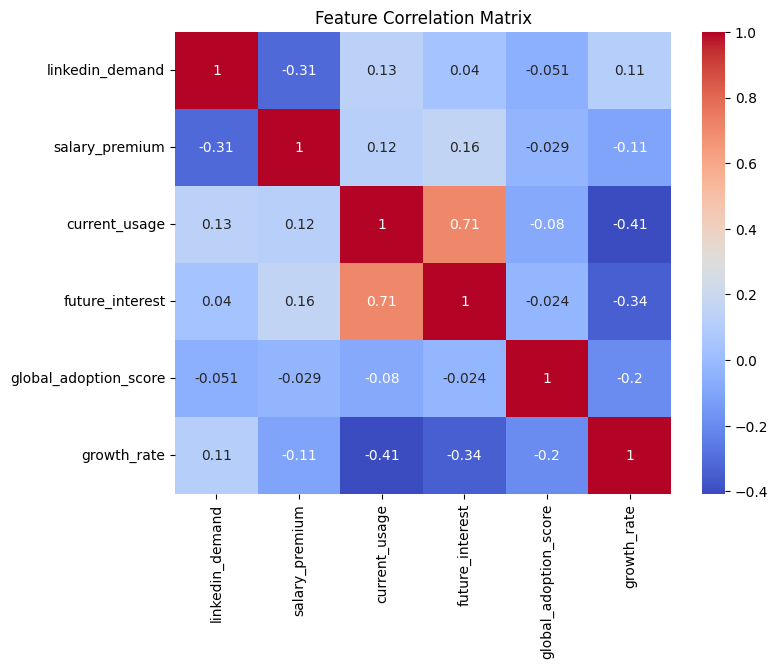

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(
    df[feature_cols].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title('Feature Correlation Matrix')
plt.show()

In [42]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

components = pca.fit_transform(X_scaled)

df['pc1'] = components[:,0]
df['pc2'] = components[:,1]

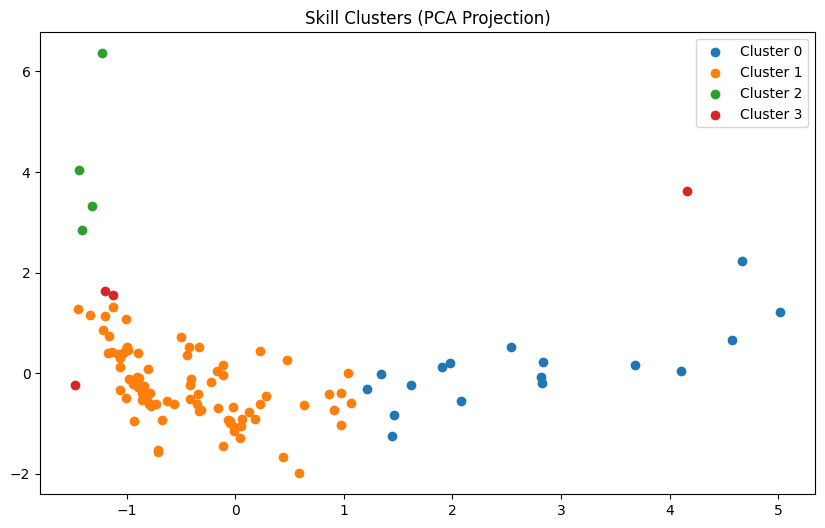

In [43]:
plt.figure(figsize=(10,6))

for cluster in sorted(df['cluster'].unique()):

    subset = df[df['cluster']==cluster]

    plt.scatter(
        subset['pc1'],
        subset['pc2'],
        label=f'Cluster {cluster}'
    )

plt.legend()
plt.title('Skill Clusters (PCA Projection)')
plt.show()